In [27]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

from pandas.core.arrays import timedeltas

In [59]:

# Download latest version
path = kagglehub.dataset_download("imakash3011/customer-personality-analysis")

df = pd.read_csv(path+'/marketing_campaign.csv', sep='\t')

In [60]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


## 1-1 Feature Engineering
Let data collect date is 2014-08-01
1. Year_Birth to Age
2. Dt_Customer to Enrollment_days
3. Mnt* to TotalSpent
4. Accepted* to TotalCmp

In [61]:
df_eng = df.copy(deep=True)

In [62]:
df_eng['Age'] = 2014-df['Year_Birth']

(array([ 61., 240., 394., 540., 350., 336., 260.,  54.,   2.,   0.,   0.,
          0.,   0.,   1.,   2.]),
 array([ 18.        ,  24.86666667,  31.73333333,  38.6       ,
         45.46666667,  52.33333333,  59.2       ,  66.06666667,
         72.93333333,  79.8       ,  86.66666667,  93.53333333,
        100.4       , 107.26666667, 114.13333333, 121.        ]),
 <BarContainer object of 15 artists>)

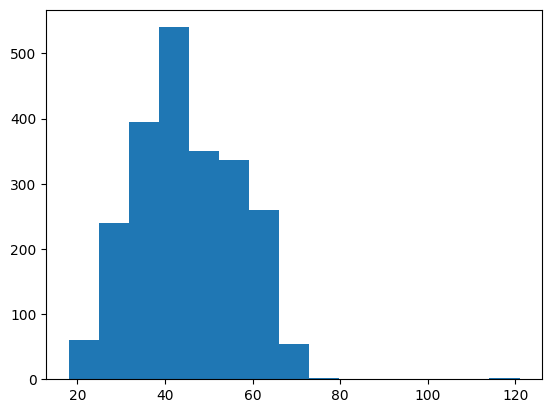

In [63]:
plt.plot()
plt.hist(df_eng['Age'], bins=15)

In [64]:
df_eng['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')

In [67]:
df_eng['Enrollment_Days'] = (datetime.strptime('2014-08-01', '%Y-%m-%d') - df_eng['Dt_Customer']).dt.days

(array([ 74.,  97.,  88.,  97.,  87.,  85.,  77.,  78.,  96., 101.,  93.,
         93.,  87.,  88.,  91.,  84.,  93., 105.,  75.,  95.,  79.,  95.,
         81., 110.,  91.]),
 array([ 33.  ,  60.96,  88.92, 116.88, 144.84, 172.8 , 200.76, 228.72,
        256.68, 284.64, 312.6 , 340.56, 368.52, 396.48, 424.44, 452.4 ,
        480.36, 508.32, 536.28, 564.24, 592.2 , 620.16, 648.12, 676.08,
        704.04, 732.  ]),
 <BarContainer object of 25 artists>)

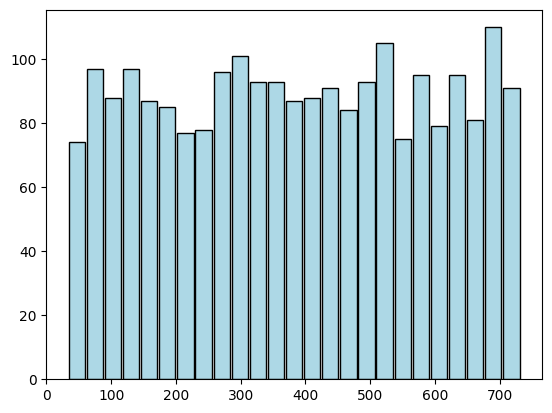

In [68]:
plt.plot()
plt.hist(df_eng['Enrollment_Days'], bins=25, color='lightblue',edgecolor='black', rwidth=0.90)

In [69]:
df_eng['Total_Spent'] = df['MntFishProducts'] + df['MntFruits'] + df['MntWines'] + df['MntSweetProducts'] + df['MntGoldProds'] + df['MntMeatProducts']

(array([731., 175., 127., 107., 115.,  75.,  68.,  79.,  84.,  91.,  86.,
         91.,  60.,  60.,  56.,  56.,  46.,  36.,  29.,  24.,  20.,   9.,
          7.,   3.,   5.]),
 array([   5. ,  105.8,  206.6,  307.4,  408.2,  509. ,  609.8,  710.6,
         811.4,  912.2, 1013. , 1113.8, 1214.6, 1315.4, 1416.2, 1517. ,
        1617.8, 1718.6, 1819.4, 1920.2, 2021. , 2121.8, 2222.6, 2323.4,
        2424.2, 2525. ]),
 <BarContainer object of 25 artists>)

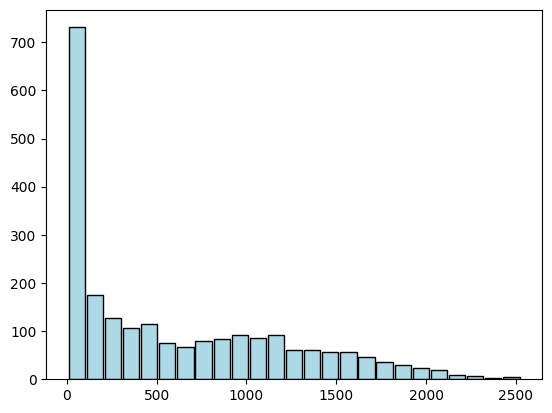

In [70]:
plt.plot()
plt.hist(df_eng['Total_Spent'], bins=25, color='lightblue',edgecolor='black', rwidth=0.90)

In [71]:
df_eng['Total_Acp'] = df['AcceptedCmp1'] +df['AcceptedCmp2'] +df['AcceptedCmp3'] +df['AcceptedCmp4'] +df['AcceptedCmp5']

(array([1777.,  325.,   83.,   55.]),
 array([0., 1., 2., 3., 4.]),
 <BarContainer object of 4 artists>)

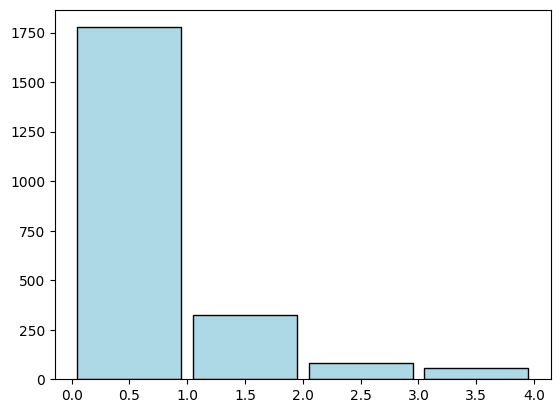

In [72]:
plt.plot()
plt.hist(df_eng['Total_Acp'], bins=4, color='lightblue',edgecolor='black', rwidth=0.90)

## 1-2 Dirty Data Cleaning

1. Delete Z* columns
2. 위에서 변환한 피쳐들 제거
3. Delete Missing value (Income)

In [78]:
df_clean = df_eng.drop(['Z_CostContact','Z_Revenue'],axis=1)
df_clean = df_clean.drop(['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5'],axis=1)
df_clean = df_clean.drop(['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds'],axis=1)
df_clean = df_clean.drop(['Dt_Customer','Year_Birth'],axis=1)

In [79]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Education            2240 non-null   str    
 2   Marital_Status       2240 non-null   str    
 3   Income               2216 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Recency              2240 non-null   int64  
 7   NumDealsPurchases    2240 non-null   int64  
 8   NumWebPurchases      2240 non-null   int64  
 9   NumCatalogPurchases  2240 non-null   int64  
 10  NumStorePurchases    2240 non-null   int64  
 11  NumWebVisitsMonth    2240 non-null   int64  
 12  Complain             2240 non-null   int64  
 13  Response             2240 non-null   int64  
 14  Age                  2240 non-null   int64  
 15  Enrollment_Days      2240 non-null   int64  
 16 

In [80]:
df_clean = df_clean.dropna(axis=0)

In [81]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2216 non-null   int64  
 1   Education            2216 non-null   str    
 2   Marital_Status       2216 non-null   str    
 3   Income               2216 non-null   float64
 4   Kidhome              2216 non-null   int64  
 5   Teenhome             2216 non-null   int64  
 6   Recency              2216 non-null   int64  
 7   NumDealsPurchases    2216 non-null   int64  
 8   NumWebPurchases      2216 non-null   int64  
 9   NumCatalogPurchases  2216 non-null   int64  
 10  NumStorePurchases    2216 non-null   int64  
 11  NumWebVisitsMonth    2216 non-null   int64  
 12  Complain             2216 non-null   int64  
 13  Response             2216 non-null   int64  
 14  Age                  2216 non-null   int64  
 15  Enrollment_Days      2216 non-null   int64  
 16  Tota

## 1-3. DataInspecting